# Lab 1 – podstawowa analiza obrazu

W tym ćwiczeniu samodzielnie przeprowadzisz podstawową analizę obrazu cyfrowego z wykorzystaniem biblioteki `scikit-image`.

Twoim celem jest przejście przez cały prosty proces analizy:

**wczytanie obrazu → sprawdzenie jego właściwości → analiza kanałów → skala szarości → histogram → normalizacja → wyrównanie histogramu**


## 1. Wybierz obraz

Wybierz jeden obraz z wbudowanej bazy:

```python
skimage.data
```

Możesz wykorzystać np.:

```python
data.camera()
data.coins()
data.chelsea()
data.coffee()
data.horse()
data.moon()
data.rocket()
```

Nie wybieraj obrazu `astronaut`, ponieważ był już analizowany podczas zajęć.

Wyświetl wybrany obraz.


In [351]:
from skimage import data, color, exposure, img_as_float
import numpy as np
import matplotlib.pyplot as plt

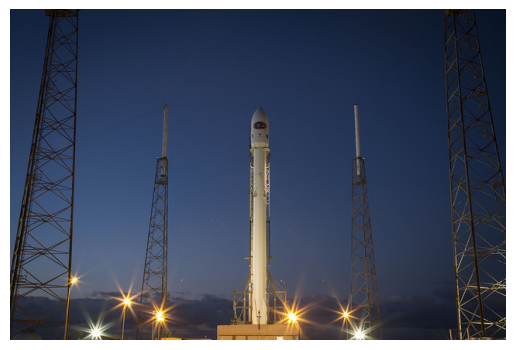

In [352]:
img = data.rocket()

plt.imshow(img)
plt.axis("off")
plt.show()

## 2. Sprawdź podstawowe informacje o obrazie

Sprawdź:

```python
img.shape
img.dtype
img.min()
img.max()
```

Zwróć uwagę na:

- wymiary obrazu,
- liczbę kanałów,
- typ danych,
- minimalną i maksymalną wartość pikseli.

### Zastanów się

Co informacje zwracane przez `shape` mówią o obrazie?  
Czy wartości pikseli są zapisane w zakresie `0–255`, czy `0–1`?


In [353]:
print("shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min())
print("max:", img.max())


shape: (427, 640, 3)
dtype: uint8
min: 0
max: 255


## 3. Określ rodzaj obrazu

Na podstawie wymiarów określ, czy obraz jest:

- obrazem w skali szarości,
- obrazem RGB,
- obrazem RGBA.

Przykładowo:

```text
(wysokość, szerokość)
```

oznacza zazwyczaj obraz w skali szarości,

natomiast:

```text
(wysokość, szerokość, 3)
```

oznacza obraz RGB.


## 4. Przeanalizuj kanały obrazu

Jeżeli wybrany obraz jest obrazem RGB, wydziel jego trzy kanały:

- R – czerwony,
- G – zielony,
- B – niebieski.

Wyświetl obok siebie:

**obraz RGB | kanał R | kanał G | kanał B**

Kanały możesz wyświetlić w skali szarości, ponieważ wtedy jasność piksela pokazuje intensywność danego kanału.

### Zastanów się

W których fragmentach obrazu poszczególne kanały są najjaśniejsze?  
Czy da się powiązać to z kolorami widocznymi na obrazie oryginalnym?

Jeśli obraz jest już w skali szarości, pomiń ten etap.


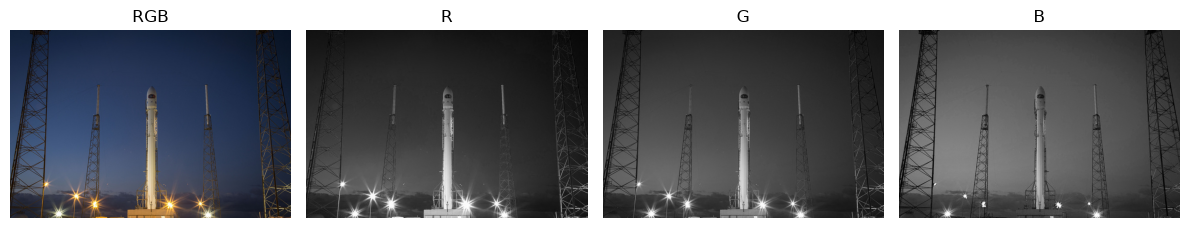

In [354]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for ax in axes:
    ax.axis("off")

axes[0].imshow(img)
axes[0].set_title("RGB")

red = img[:, :, 0]
green = img[:, :, 1]
blue = img[:, :, 2]

axes[1].imshow(red, cmap="gray")
axes[1].set_title("R")

axes[2].imshow(green, cmap="gray")
axes[2].set_title("G")

axes[3].imshow(blue, cmap="gray")
axes[3].set_title("B")

plt.tight_layout()
plt.show()



## 5. Przekonwertuj obraz do skali szarości

Jeżeli obraz jest kolorowy, przekonwertuj go do skali szarości:

```python
gray = color.rgb2gray(img)
```

Wyświetl obraz przed i po konwersji.

Ponownie sprawdź:

```python
gray.shape
gray.dtype
gray.min()
gray.max()
```

### Zastanów się

Co zmieniło się w strukturze danych po usunięciu informacji o kolorze?


In [355]:
if (len(img.shape) > 2):
    img_grayscale = color.rgb2gray(img)
else:
    img_grayscale = img

print("shape:", img_grayscale.shape)
print("dtype:", img_grayscale.dtype)
print("min:", img_grayscale.min())
print("max", img_grayscale.max())


img_grayscale = gray_8bit = (img_grayscale * 255).astype(np.uint8)

print("shape:", img_grayscale.shape)
print("dtype:", img_grayscale.dtype)
print("min:", img_grayscale.min())
print("max", img_grayscale.max())


shape: (427, 640)
dtype: float64
min: 0.0
max 1.0
shape: (427, 640)
dtype: uint8
min: 0
max 255


## 6. Narysuj histogram jasności

Dla obrazu w skali szarości utwórz histogram.

Użyj:

```python
bins=256
```

Pamiętaj, aby zakres histogramu odpowiadał zakresowi wartości pikseli.

Dla obrazu w zakresie `0–1`:

```python
range=(0, 1)
```

Dla obrazu w zakresie `0–255`:

```python
range=(0, 255)
```

Podpisz osie:

- oś X – poziom jasności,
- oś Y – liczba pikseli.

### Zastanów się

Czy większość pikseli znajduje się w obszarze ciemnych, średnich czy jasnych wartości?  
Czy histogram wykorzystuje szeroki zakres intensywności, czy wartości są skupione w niewielkim obszarze?


In [356]:
def plot(images, titles=None):
    n = len(images)
    fig, axes = plt.subplots(2, n, figsize=(6*n, 6), height_ratios=[1, 2])
    axes = np.array(axes).reshape(2, n)
    for i, img in enumerate(images):
        ax = axes[0][i]
        minval = img.min()
        maxval = img.max()
        hist, bins = np.histogram(
            img.flatten(),
            bins=256,
            range=(minval, maxval)
        )
        if titles:
            ax.set_title(titles[i])
        ax.set_xlabel("Brightness")
        ax.set_ylabel("Pixel count")
        ax.set_xlim([minval, maxval])
        ax.set_xticks(np.linspace(minval, maxval, 6))
        ax.plot(bins[:-1], hist)
        ax.fill_between(bins[:-1], hist, alpha=0.3)
        axes[1][i].imshow(img, cmap="gray")
        axes[1][i].axis("off")

    plt.tight_layout()
    plt.show()


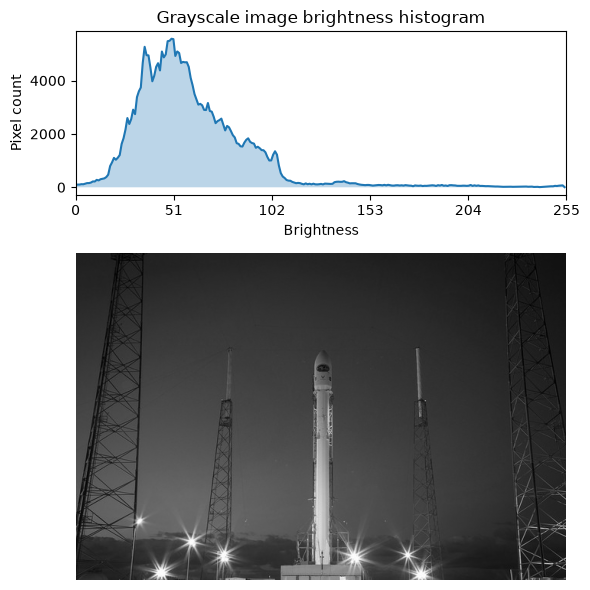

In [357]:
plot([img_grayscale], ["Grayscale image brightness histogram"])

## 7. Wykonaj normalizację

Wykonaj normalizację obrazu za pomocą:

```python
exposure.rescale_intensity()
```

Przeskaluj wartości pikseli do zakresu:

```text
0–1
```

Wyświetl:

**obraz przed normalizacją | obraz po normalizacji**

Narysuj również histogramy obu obrazów.

### Zastanów się

Czy zakres wartości został rozciągnięty?  
Czy kontrast obrazu zmienił się zauważalnie?  
Jeżeli zmiana jest niewielka, spróbuj wyjaśnić, z czego może to wynikać.


float64


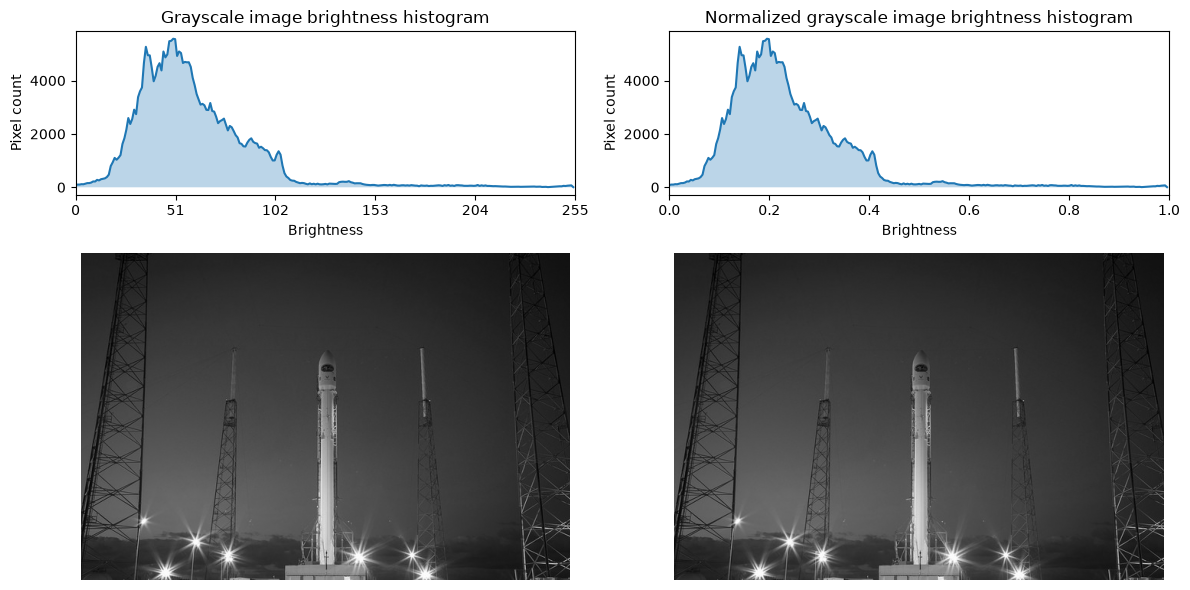

In [358]:
img_grayscale_normalized = exposure.rescale_intensity(
    img_grayscale,
    out_range=(0, 1)
)
print(img_grayscale_normalized.dtype)
plot([img_grayscale, img_grayscale_normalized], ["Grayscale image brightness histogram", "Normalized grayscale image brightness histogram"])

## 8. Wykonaj wyrównanie histogramu

Wykonaj wyrównanie histogramu:

```python
exposure.equalize_hist()
```

Wyświetl:

**obraz przed wyrównaniem | obraz po wyrównaniu**

Narysuj histogram obrazu wynikowego.

### Zastanów się

Jak zmienił się rozkład poziomów jasności?  
Czy szczegóły obrazu stały się bardziej widoczne?  
Czy histogram jest bardziej rozłożony w całym dostępnym zakresie?


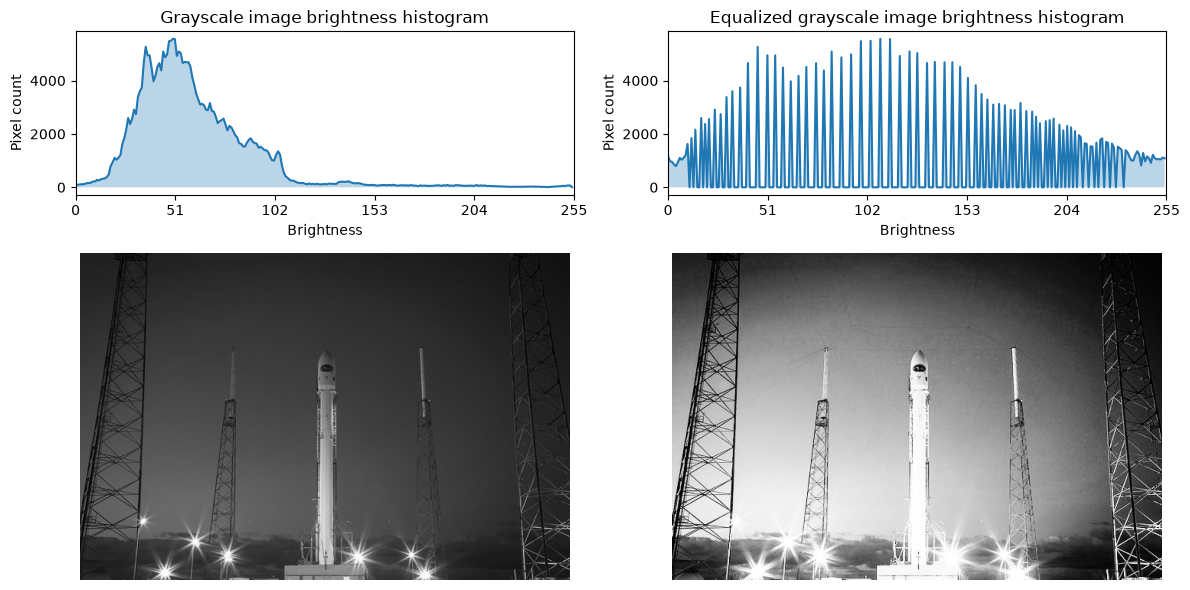

In [359]:
img_grayscale_equalized = exposure.rescale_intensity(exposure.equalize_hist(img_grayscale), out_range = (0, 255))
plot([img_grayscale, img_grayscale_equalized], ["Grayscale image brightness histogram", "Equalized grayscale image brightness histogram"])


## 9. Porównaj wyniki

Na jednej figurze wyświetl:

```text
Oryginał | Normalizacja | Wyrównanie histogramu
```

Poniżej umieść odpowiadające im histogramy.

Porównaj wygląd obrazów i rozkład intensywności.

### Zastanów się nad różnicą pomiędzy normalizacją i wyrównaniem histogramu

Normalizacja przede wszystkim rozciąga zakres wartości, natomiast wyrównanie histogramu zmienia sposób rozmieszczenia intensywności w tym zakresie.


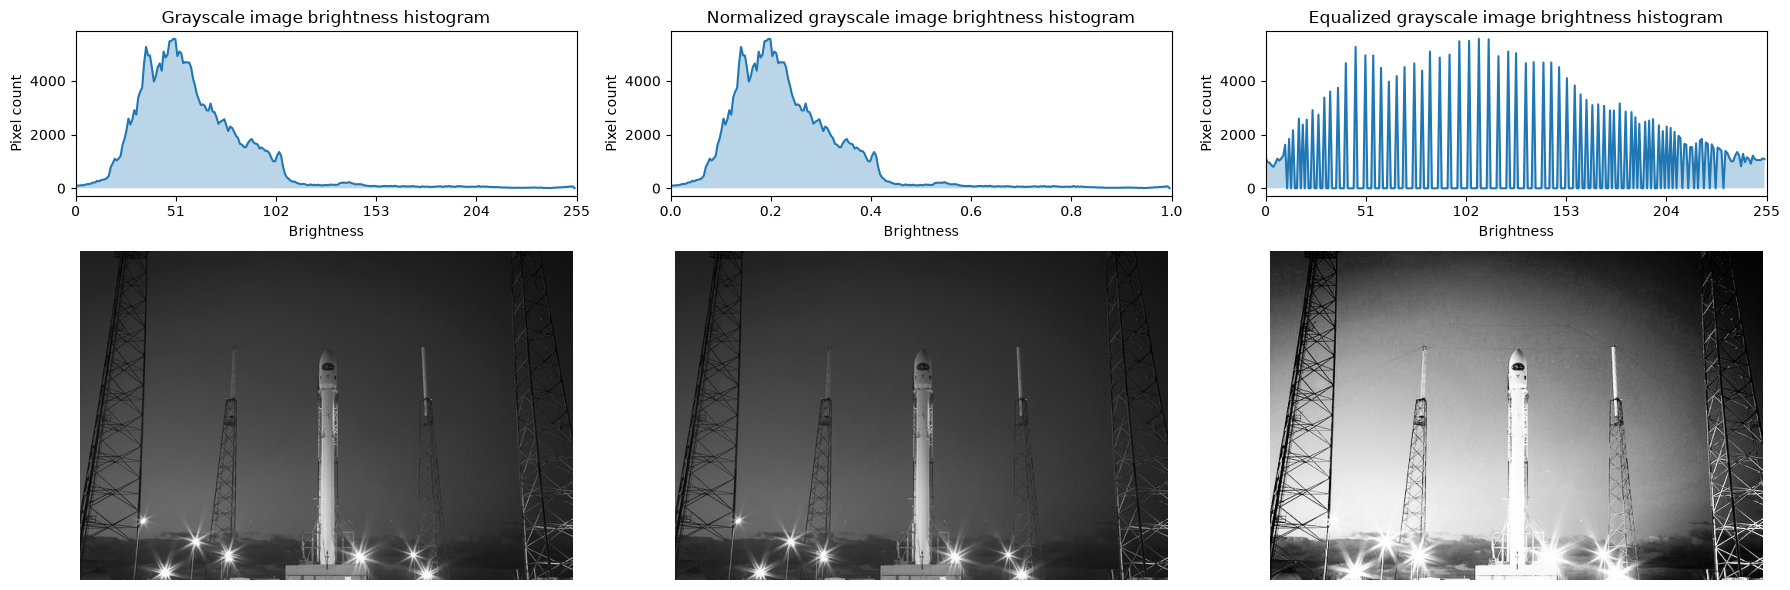

In [360]:
images = [img_grayscale, img_grayscale_normalized, img_grayscale_equalized]
titles = ["Grayscale image brightness histogram", "Normalized grayscale image brightness histogram", "Equalized grayscale image brightness histogram"]
plot(images, titles)

